In [1]:
try:
    import xgboost as xgb
except:
    !uv pip install xgboost
    import xgboost as xgb

xgb.__version__

'3.2.0'

In [2]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic (GPU/CPU) --
def get_system_info():
    if torch.cuda.is_available():
        return f"GPU: {torch.cuda.get_device_name(0)}"
    else:
        return f"CPU: {os.cpu_count()}"

get_system_info()

'GPU: Tesla T4'

In [3]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
import itertools
from time import time, sleep
from tqdm.notebook import tqdm

## -- Machine Learning --
import sklearn
from sklearn.calibration import CalibrationDisplay
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

In [4]:
## -- Set Configuration --
# sklearn.set_config(transform_output="pandas")
# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use('ggplot')

# plt.rcParams['axes.prop_cycle'] = cycler(color=['red', 'green', 'blue'])
plt.rcParams.update({
    # "figure.facecolor": '#0f0f1a', # Outer panel (figure)
    # "axes.facecolor":   '#1a1a2e', # Inner panel (image)
    # "axes.edgecolor":   '#444466',
    # "axes.labelcolor":  '#e0e0ff',
    # "text.color":       'lightblue',
    # "xtick.color":      '#e0e0ff',
    # "ytick.color":      '#e0e0ff',
    # "grid.color":       '#2a2a4a',
    # "grid.alpha":       0.5,
    "font.family":      'monospace',
})

PALETTE = ['c', 'r', 'darkorange', '#3A86FF', 'y']
sns.set_palette(PALETTE)
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
CFG = {
    'FOLDS': 5,
    'SEED': 42,
    'GREEN': '\033[32m',
    'YELLOW': '\033[33m',
    'RESET': '\033[0m'
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [5]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = 'kaggle' # -> 'colab' 'kaggle'

if PLATFORM == 'kaggle':
    PATH = '/kaggle/input/competitions/playground-series-s6e8/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')

    # ORIG_PATH = '/kaggle/input/datasets/ziya07/college-student-health-behavior-dataset/'
    # orig = pd.read_csv(ORIG_PATH+'student_health_dataset_50k.csv')
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = '/content/drive/MyDrive/-- shared_notebooks --/Ps6e8 | Phone Addiction/_phone_addiction_data/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')
    # orig = pd.read_csv(PATH+'student_health_dataset_50k.csv')

## =================================================================================

ID      = 'id'
TARGET  = 'addicted_label'
OBJECTS = train.select_dtypes(include=['object', 'category']).columns.tolist()

CATS = [c for c in OBJECTS if c not in [TARGET, ID]]
NUMS = [c for c in train.columns if c not in CATS+[TARGET, ID]]
BASE = NUMS + CATS

for (name, df) in {'Train': train, 'Test': test}.items(): # , 'Orig': orig
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (691369, 14)
Test shape: (296302, 13)

Total Numerical: 9
Total Categorical: 3
Total base features: 12


In [6]:
display(train.head())
train.info()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  object 
 11  stress_level             636221 non-null  object 
 12  academic_work_impact     647145 non-null  object 
 13  addicted_label           691369 non-null  int64  
dtypes: f

In [7]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,691369.0,345684.000000,199581.183466,0.00,172842.00,345684.00,518526.00,691368.00
age,662440.0,26.615408,5.153162,18.00,22.00,27.00,31.00,35.00
daily_screen_time_hours,595515.0,7.640865,2.721446,0.50,5.48,7.77,9.84,15.00
social_media_hours,557374.0,2.471038,1.316137,0.00,1.45,2.31,3.37,8.00
gaming_hours,564548.0,1.459265,0.934552,0.00,0.70,1.33,2.09,4.00
work_study_hours,639851.0,2.366971,1.258797,0.00,1.36,2.20,3.20,6.00
sleep_hours,646889.0,6.804334,1.234512,4.50,5.78,6.80,7.87,9.00
notifications_per_day,623785.0,145.894900,65.917556,20.00,93.00,150.00,204.00,250.00
app_opens_per_day,610659.0,102.636781,48.093970,15.00,64.00,104.00,145.00,180.00
weekend_screen_time,579306.0,9.479866,2.856006,0.51,7.28,9.58,11.75,17.56


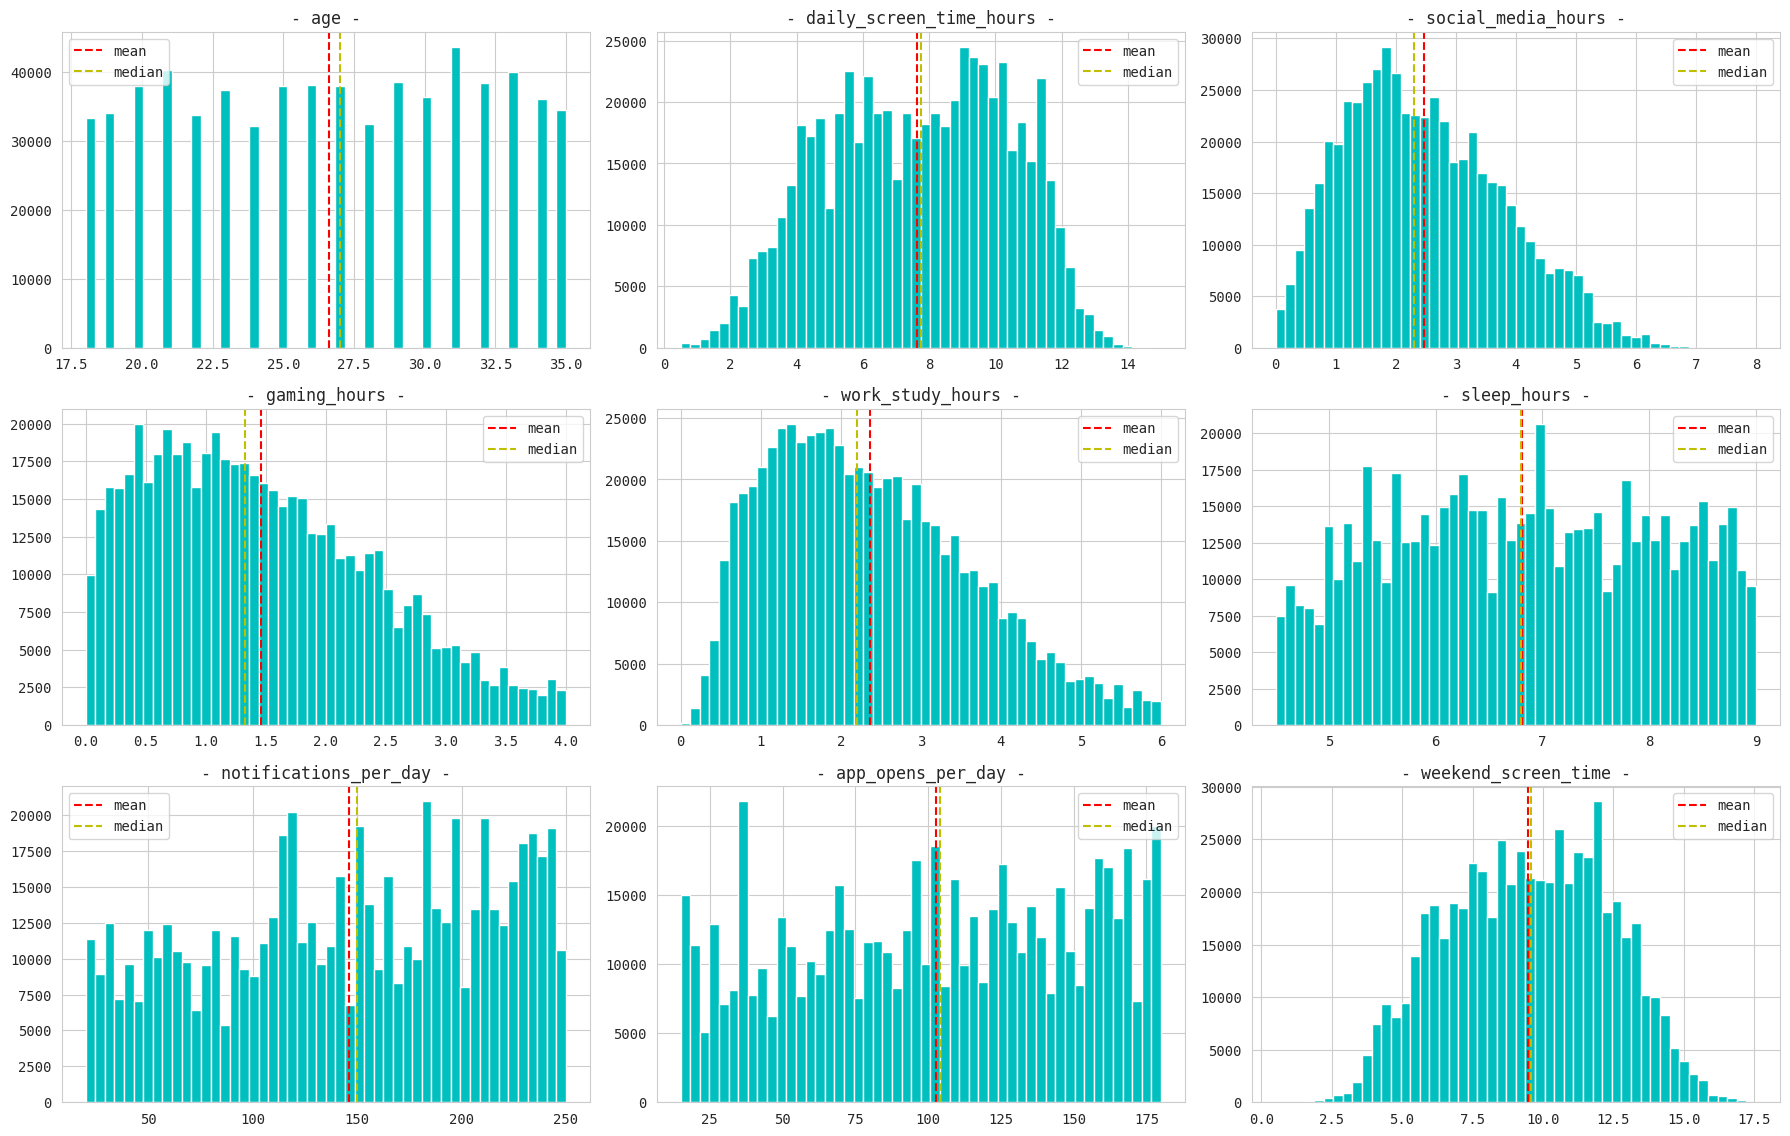

In [8]:
plt.figure(figsize=(18, 15))

for i, col in enumerate(NUMS):
    plt.subplot(4, 3, i+1)
    ax = plt.hist(train[col], bins=50)
    plt.axvline(x=train[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=train[col].median(), color='y', linestyle='--', label='median')
    plt.title(f'- {col} -')
    plt.legend()

plt.tight_layout()
plt.show()

In [9]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {} 
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    # ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         # pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.T.style.background_gradient()

,Train,Test
age,18,18
daily_screen_time_hours,1389,1349
social_media_hours,721,703
gaming_hours,401,401
work_study_hours,600,601
sleep_hours,451,451
notifications_per_day,231,231
app_opens_per_day,166,166
weekend_screen_time,1437,1404
gender,3,3


In [10]:
n_unique = train[BASE].nunique().sort_values()
n_unique

academic_work_impact          2
gender                        3
stress_level                  3
age                          18
app_opens_per_day           166
notifications_per_day       231
gaming_hours                401
sleep_hours                 451
work_study_hours            600
social_media_hours          721
daily_screen_time_hours    1389
weekend_screen_time        1437
dtype: int64

## FEATURE ENGINEERING

In [11]:
## -- EXTRACTIONS & BINNING --
ROUNDS = []
DIGITS = []
E_BINS = []
Q_BINS = []
DROP_COLS = []

round_thresh = 3
digit_thresh = 2

round_thresh, digit_thresh

(3, 2)

In [12]:
for col in NUMS:
    # print(f"\nRounding... ", end='')
    # for r in range(-2, 3):
    #     r_n = f"{col}_round_{r}"
    #     print(r_n+', ', end='')
    #     train[r_n] = train[col].round(r).astype('int32')
    #     test[r_n]  = test[col].round(r).astype('int32')
    #     orig[r_n]  = orig[col].round(r).astype('int32')

    #     ## -- Drop irrelevant features --
    #     if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
    #         DROP_COLS.append(r_n)
    #     else:
    #         ROUNDS.append(r_n)

    print(f"\nDIGITS... ", end='')
    for d in range(-3, 3):
        d_n = f'{col}_digit_{d}'
        print(d_n+', ', end='')
        train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int32')
        test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int32')
        # orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

        ## -- Drop constant features --
        if train[d_n].nunique() < digit_thresh:
            DROP_COLS.append(d_n)
        else:
            DIGITS.append(d_n)

    # print(f"\nCreating value-based E_BINS... ", end='')
    # for b in [100]:
    #     b_n = f'{col}_bin_{b}'
    #     print(b_n+', ', end='')
    #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
    #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     E_BINS.append(b_n)

    # print(f"\nCreating quantile-based Q_BINS... ", end='')
    # for q in [100]:
    #     q_n = f'{col}_Qbin_{q}'
    #     print(q_n+', ', end='')
    #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
    #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     Q_BINS.append(q_n)

print()
print('='*50)
print(f'✅ Total ROUNDS: {len(ROUNDS)}')
print(f"✅ Total DIGITS: {len(DIGITS)}")
print(f"✅ Total E_BINS: {len(E_BINS)}")
print(f"✅ Total Q_BINS: {len(Q_BINS)}")


DIGITS... age_digit_-3, age_digit_-2, age_digit_-1, age_digit_0, age_digit_1, age_digit_2, 
DIGITS... daily_screen_time_hours_digit_-3, daily_screen_time_hours_digit_-2, daily_screen_time_hours_digit_-1, daily_screen_time_hours_digit_0, daily_screen_time_hours_digit_1, daily_screen_time_hours_digit_2, 
DIGITS... social_media_hours_digit_-3, social_media_hours_digit_-2, social_media_hours_digit_-1, social_media_hours_digit_0, social_media_hours_digit_1, social_media_hours_digit_2, 
DIGITS... gaming_hours_digit_-3, gaming_hours_digit_-2, gaming_hours_digit_-1, gaming_hours_digit_0, gaming_hours_digit_1, gaming_hours_digit_2, 
DIGITS... work_study_hours_digit_-3, work_study_hours_digit_-2, work_study_hours_digit_-1, work_study_hours_digit_0, work_study_hours_digit_1, work_study_hours_digit_2, 
DIGITS... sleep_hours_digit_-3, sleep_hours_digit_-2, sleep_hours_digit_-1, sleep_hours_digit_0, sleep_hours_digit_1, sleep_hours_digit_2, 
DIGITS... notifications_per_day_digit_-3, notifications_p

In [13]:
train = train.drop(columns=DROP_COLS)
test  = test.drop(columns=DROP_COLS)
# orig  = orig.drop(columns=DROP_COLS)

print(f"Features dropped: {DROP_COLS}")

Features dropped: []


In [14]:
train[ROUNDS+DIGITS+E_BINS+Q_BINS].nunique()

age_digit_-3                         2
age_digit_-2                         2
age_digit_-1                         4
age_digit_0                         11
age_digit_1                          2
age_digit_2                          2
daily_screen_time_hours_digit_-3     2
daily_screen_time_hours_digit_-2     2
daily_screen_time_hours_digit_-1     3
daily_screen_time_hours_digit_0     11
daily_screen_time_hours_digit_1     11
daily_screen_time_hours_digit_2     11
social_media_hours_digit_-3          2
social_media_hours_digit_-2          2
social_media_hours_digit_-1          2
social_media_hours_digit_0          10
social_media_hours_digit_1          11
social_media_hours_digit_2          11
gaming_hours_digit_-3                2
gaming_hours_digit_-2                2
gaming_hours_digit_-1                2
gaming_hours_digit_0                 6
gaming_hours_digit_1                11
gaming_hours_digit_2                11
work_study_hours_digit_-3            2
work_study_hours_digit_-2

In [15]:
# def add_frequency_condition(df1, cols, thresh=5): 
#     df = df1.copy()
#     for c in cols:
#         v_counts = df[c].value_counts()
#         to_replace = v_counts[v_counts <= thresh].index
#         df[c] = np.where(df[c].isin(to_replace), -1, df[c])

#     return df

# train = add_frequency_condition(train, DIGITS+ROUNDS, thresh=5)
# test  = add_frequency_condition(test,  DIGITS+ROUNDS, thresh=5)
# orig  = add_frequency_condition(orig,  DIGITS+ROUNDS, thresh=5)

# print(f"Frequency threshold imputed!")

In [16]:
## -- Frequency encoding --
FREQ_COLS = []

print(f"\nCreating frequencies... ", end='')
for col in NUMS: # 'Position_Change'
    freq = pd.concat([train[col], test[col]]).value_counts(normalize=True) # orig[col], 
    n = f'{col}_freq'
    print(n+', ', end='')
    for df in [train, test]: # , orig
        df[n] = df[col].map(freq).fillna(0).astype('float32')
    FREQ_COLS.append(n)

print(f"\n✓ Total frequency features: {len(FREQ_COLS)}")
train[FREQ_COLS]


Creating frequencies... age_freq, daily_screen_time_hours_freq, social_media_hours_freq, gaming_hours_freq, work_study_hours_freq, sleep_hours_freq, notifications_per_day_freq, app_opens_per_day_freq, weekend_screen_time_freq, 
✓ Total frequency features: 9


,age_freq,daily_screen_time_hours_freq,social_media_hours_freq,gaming_hours_freq,work_study_hours_freq,sleep_hours_freq,notifications_per_day_freq,app_opens_per_day_freq,weekend_screen_time_freq
0,0.048647,0.000000,0.003290,0.003272,0.004588,0.004508,0.005788,0.008364,0.002754
1,0.051449,0.001858,0.002096,0.000000,0.001695,0.000911,0.008656,0.006304,0.000000
2,0.050199,0.000807,0.000000,0.000000,0.000000,0.006240,0.002401,0.004550,0.001919
3,0.060722,0.000938,0.003062,0.003177,0.002585,0.002531,0.009864,0.005940,0.000735
4,0.057575,0.000549,0.003978,0.002300,0.003191,0.002848,0.000000,0.000000,0.000638
...,...,...,...,...,...,...,...,...,...
691364,0.051199,0.001045,0.003354,0.004017,0.004069,0.003290,0.003289,0.005940,0.002169
691365,0.057368,0.001341,0.004068,0.002797,0.000549,0.004163,0.005939,0.011147,0.003234
691366,0.000000,0.000000,0.000000,0.000000,0.003335,0.001894,0.000000,0.002395,0.001529
691367,0.051199,0.001638,0.002188,0.002592,0.004219,0.001178,0.003195,0.003110,0.002057


In [17]:
# INTER = []

# for c1, c2 in tqdm(list(itertools.combinations(DIGITS, 2)), desc='Pairwise'):
#     n_col = f"Bi_{c1}-|-{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     # orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

# # for c1, c2, c3 in tqdm(list(itertools.combinations(CATS, 3)), desc='Triplewise'):
# #     n_col = f"Tri_{c1}-|-{c2}-|-{c3}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
# #     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + test[c3].astype(str)
# #     INTER.append(n_col)

# # for c1, c2 in tqdm(list(itertools.product(CATS, DIGITS)), desc='One-to-Many'):
# #     n_col = f"Bi_{c1}-|-{c2}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
# #     # orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
# #     INTER.append(n_col)

# print(f"Total Interaction Features: {len(INTER)}")

In [18]:
# ## -- Arithmetic interactions --
# for df in [train, test]: # , orig
#     # df["_weeknd_X_daily"] = (
#     #                                     df["weekend_screen_time"] + \
#     #                                     df["daily_screen_time_hours"]).astype('float32')
#     # df["_gaming_X_daily_X_social"] = (
#     #                                     df["gaming_hours"] + \
#     #                                     df["daily_screen_time_hours"] + \
#     #                                     df["social_media_hours"]).astype('float32')
#     df["_daily_X_social_X_weekend"] = (
#                                         df["daily_screen_time_hours"] + \
#                                         df["social_media_hours"] + \
#                                         df["weekend_screen_time"]).astype("float32")
#     # df["_daily_X_social_X_work_/_sleep"] = ((
#     #                                     df["daily_screen_time_hours"] + \
#     #                                     df["social_media_hours"] + \
#     #                                     df["work_study_hours"]) / (df["sleep_hours"]+1e-8)).astype('float32')

# ARITHMETIC_COLS = [
#     # "_weeknd_X_daily",
#     # "_gaming_X_daily_X_social",
#     "_daily_X_social_X_weekend",
#     # "_daily_X_social_X_work_/_sleep",
#     # '_LapTime (s)_*_Cum_Deg_abs',
#     # '_LapTime (s)_/_Cum_Deg_abs',
# ]

# print(f"Total Arithmetic interactions: {len(ARITHMETIC_COLS)}")

# train[ARITHMETIC_COLS]

In [19]:
# ## -- Cyclic encoding --
# for df in [train, test]:
#     for p in [8, 12, 24]:
#         df[f"sleep_hours_sin_{p}"] = np.sin(2 * np.pi * df["sleep_hours"] / p).astype("float32")
#         df[f"sleep_hours_cos_{p}"] = np.cos(2 * np.pi * df["sleep_hours"] / p).astype("float32")

In [20]:
# ## -- Reduce data memory --
# def reduce_memory(df):
#     old_size = sys.getsizeof(df) / (1024*1024)
#     for c in tqdm(df.columns, desc='Reducing memory...'):
#         ## -- Downcast Integer type ---
#         if df[c].dtype == np.int64: 
#             if df[c].min() > np.iinfo(np.int32).min and df[c].max() < np.iinfo(np.int32).max:
#                 df[c] = df[c].astype(np.int32)
#                 # if df[c].min() > np.iinfo(np.int16).min and df[c].max() < np.iinfo(np.int16).max:
#                 #     df[c] = df[c].astype(np.int16)
#                 #     if df[c].min() > np.iinfo(np.int8).min and df[c].max() < np.iinfo(np.int8).max:
#                 #         df[c] = df[c].astype(np.int8)
#         ## -- Downcast Float type -----
#         # elif df[c].dtype == np.float64:
#         #     if df[c].min() > np.finfo(np.float32).min and df[c].max() < np.finfo(np.float32).max:
#         #         df[c] = df[c].astype(np.float32)
#                 # if df[c].min() > np.finfo(np.float16).min and df[c].max() < np.finfo(np.float16).max:
#                 #     df[c] = df[c].astype(np.float16)

#     new_size = sys.getsizeof(df) / (1024*1024)
#     print(f"Size before process: {old_size:.1f}MB")
#     print(f"Size after process : {new_size:.1f}MB\n")
    
#     return df

# train = reduce_memory(train)
# test = reduce_memory(test)
# orig = reduce_memory(orig)

# gc.collect()

# print(f"Data memory reduced!")

In [21]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/Category Mean ENCODERS =====

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the
        global mean. If 'auto', an empirical Bayes estimate is used.

    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping

        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)

        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]

            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'

                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)

                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()

                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups

                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)

                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [22]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col))
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col))
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()
    
    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [23]:
# train, test, _, orig_cols = orig_TE_data_propagate(
#     orig,
#     train,
#     test,
#     train.iloc[:500],
#     features=n_unique.index[:10].tolist(),
#     target=TARGET,
#     aggs=['mean'], # mean, median, count, std, skew, nunique, max, min
#     # fill_nan=True,
# )

# print(f"Original features merged: {len(orig_cols)}")

In [24]:
## -- Duplicate all numerics as categories --
CATS_2 = []

for c in NUMS:
    n = f"cat_{c}"
    train[n] = train[c].copy()
    test[n]  = test[c].copy()
    # orig[n]  = orig[c].copy()
    CATS_2.append(n)

    ## -- Factorize -- 
    combined  = pd.concat([train[n], test[n]]) # , orig[n]
    cat_v = combined.factorize()[0]
    cat_v = pd.Series(cat_v).astype('category')
    train[n] = cat_v[:len(train)].astype('int32')
    test[n]  = cat_v[len(train):len(train)+len(test)].astype('int32')
    # orig[n]  = __[len(train)+len(test):].astype('int32')

del combined, cat_v
print(f"Nums to Cats: {len(CATS_2)}")

CATS_2

Nums to Cats: 9


['cat_age',
 'cat_daily_screen_time_hours',
 'cat_social_media_hours',
 'cat_gaming_hours',
 'cat_work_study_hours',
 'cat_sleep_hours',
 'cat_notifications_per_day',
 'cat_app_opens_per_day',
 'cat_weekend_screen_time']

In [25]:
## -- Factorize combined data --
for c in CATS:
    combined = pd.concat([train[c], test[c]]) # , orig[c]
    cat_v = combined.factorize()[0]
    cat_v = pd.Series(cat_v).astype('category')
    train[c] = cat_v[:len(train)]
    test[c]  = cat_v[len(train):len(train)+len(test)]
    # orig[c]  = combined[-len(orig):]

del combined, cat_v
print("Label encoding complete!")

Label encoding complete!


In [26]:
FEATURES = [c for c in train.columns if c not in [ID, TARGET]]
print('Total Features:', len(FEATURES))

train

Total Features: 84


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label,age_digit_-3,age_digit_-2,age_digit_-1,age_digit_0,age_digit_1,age_digit_2,daily_screen_time_hours_digit_-3,daily_screen_time_hours_digit_-2,daily_screen_time_hours_digit_-1,daily_screen_time_hours_digit_0,daily_screen_time_hours_digit_1,daily_screen_time_hours_digit_2,social_media_hours_digit_-3,social_media_hours_digit_-2,social_media_hours_digit_-1,social_media_hours_digit_0,social_media_hours_digit_1,social_media_hours_digit_2,gaming_hours_digit_-3,gaming_hours_digit_-2,gaming_hours_digit_-1,gaming_hours_digit_0,gaming_hours_digit_1,gaming_hours_digit_2,work_study_hours_digit_-3,work_study_hours_digit_-2,work_study_hours_digit_-1,work_study_hours_digit_0,work_study_hours_digit_1,work_study_hours_digit_2,sleep_hours_digit_-3,sleep_hours_digit_-2,sleep_hours_digit_-1,sleep_hours_digit_0,sleep_hours_digit_1,sleep_hours_digit_2,notifications_per_day_digit_-3,notifications_per_day_digit_-2,notifications_per_day_digit_-1,notifications_per_day_digit_0,notifications_per_day_digit_1,notifications_per_day_digit_2,app_opens_per_day_digit_-3,app_opens_per_day_digit_-2,app_opens_per_day_digit_-1,app_opens_per_day_digit_0,app_opens_per_day_digit_1,app_opens_per_day_digit_2,weekend_screen_time_digit_-3,weekend_screen_time_digit_-2,weekend_screen_time_digit_-1,weekend_screen_time_digit_0,weekend_screen_time_digit_1,weekend_screen_time_digit_2,age_freq,daily_screen_time_hours_freq,social_media_hours_freq,gaming_hours_freq,work_study_hours_freq,sleep_hours_freq,notifications_per_day_freq,app_opens_per_day_freq,weekend_screen_time_freq,cat_age,cat_daily_screen_time_hours,cat_social_media_hours,cat_gaming_hours,cat_work_study_hours,cat_sleep_hours,cat_notifications_per_day,cat_app_opens_per_day,cat_weekend_screen_time
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,0,0,0,1,0,0,2,4,0,0,-1,-1,-1,-1,-1,-1,0,0,0,1,8,3,0,0,0,1,5,9,0,0,0,2,1,1,0,0,0,7,4,6,0,1,2,2,0,0,0,0,3,8,0,0,0,0,0,8,6,3,0.048647,0.000000,0.003290,0.003272,0.004588,0.004508,0.005788,0.008364,0.002754,0,-1,0,0,0,0,0,0,0
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,1,0,0,0,0,0,1,9,0,0,0,0,0,5,9,7,0,0,0,1,0,8,-1,-1,-1,-1,-1,-1,0,0,0,3,0,3,0,0,0,8,2,2,0,0,7,6,0,0,0,0,1,9,0,0,-1,-1,-1,-1,-1,-1,0.051449,0.001858,0.002096,0.000000,0.001695,0.000911,0.008656,0.006304,0.000000,1,0,1,-1,1,1,1,1,-1
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,1,1,1,0,0,0,1,8,0,0,0,0,0,5,0,9,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,0,0,0,6,2,5,0,1,3,4,0,0,0,0,6,0,0,0,0,0,0,7,4,7,0.050199,0.000807,0.000000,0.000000,0.000000,0.006240,0.002401,0.004550,0.001919,2,1,-1,-1,-1,2,2,2,1
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,2,1,-1,1,0,0,2,1,0,0,0,0,0,6,4,2,0,0,0,1,2,6,0,0,0,1,4,2,0,0,0,3,3,6,0,0,0,8,8,5,0,1,1,2,0,0,0,0,9,4,0,0,0,0,0,8,6,6,0.060722,0.000938,0.003062,0.003177,0.002585,0.002531,0.009864,0.005940,0.000735,3,2,2,1,2,3,3,3,2
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,1,0,0,1,0,0,2,6,0,0,0,0,1,1,2,0,0,0,0,1,8,7,0,0,0,2,8,1,0,0,0,1,9,5,0,0,0,5,2,5,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,0,0,1,3,3,9,0.057575,0.000549,0.003978,0.002300,0.003191,0.002848,0.000000,0.000000,0.000638,4,3,3,2,3,4,-1,-1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,0,-1,0,1,0,0,2,2,0,0,0,0,1,0,7,8,0,0,0,3,2,5,0,0,0,1,5,7,0,0,0,1,6,5,0,0,0,7,7,1,0,0,8,6,0,0,0,0,9,4,0,0,0,0,1,2,8,9,0.051199,0.001045,0.003354,0.004017,0.004069,0.003290,0.003289,0.005940,0.002169,12,783,374,145,109,88,168,3,786
691365,691365,20.0,3.45,1.86,0.89,0.30,6.59,22

# ML TRAINING

In [27]:
def Trainer_CV(model_name, params, train_df, test_df, features, target, kfold, cat_cols):
    print(f"\n===== Starting CV: {model_name} =====")
    t0 = time()
    
    X = train_df[features]
    y = train_df[target]

    oof_preds = np.zeros(len(X))
    test_preds = np.zeros(len(test_df))
    fold_scores = []

    if 'group_kf' in model_name:
        print("Using GROUP splits --- ")
        strat_id = y.astype(str) + '__' + X['Year'].astype(str)
        splitter = kfold.split(X, strat_id)
    else:
        print("Using REGULAR splits --- ")
        splitter = kfold.split(X, y)

    for idx, (train_idx, val_idx) in enumerate(splitter, 1):
        print(f"\n##### FOLD {idx}/{kfold.n_splits} | {get_system_info()}", end=" | ")

        X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
        X_test = test_df[features].copy()

        # ## -- OPTION A: CONCATENATE ORIGINAL DATA --
        # X_train = pd.concat([X_train, orig[features]], ignore_index=True)
        # y_train = pd.concat([y_train, orig[target]], ignore_index=True)
        # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

        # ## -- OPTION B: TE Merge original data --
        # X_train, X_valid, X_test, orig_cols = orig_TE_data_propagate(
        #     orig,
        #     X_train,
        #     X_valid,
        #     X_test,
        #     features=BASE,
        #     target=TARGET,
        #     aggs=['mean'], # mean, median, count, std, skew, nunique, max, min
        #     # fill_nan=True,
        # )

        # cme_cols = ROUNDS
        # print(f"CategoryMeanEncoding: {len(cme_cols)} | ", end='')
        # cme = CategoryMeanTransformer(cat_cols=cme_cols)
        # X_train = cme.fit_transform(X_train, y_train)
        # X_valid = cme.transform(X_valid)
        # X_test  = cme.transform(X_test)

        te_enc  = TargetEncoder(CATS_2, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
        X_train = te_enc.fit_transform(X_train, y_train)
        X_valid = te_enc.transform(X_valid)
        X_test  = te_enc.transform(X_test)
    
        # combined = pd.concat([X_train, X_valid, X_test])
        # for c in cat_cols:
        #     combined[c] = combined[c].factorize()[0]
        #     combined[c] = combined[c].astype('category')
        # X_train = combined.iloc[:len(X_train)]
        # X_valid = combined.iloc[len(X_train):len(X_train)+len(X_valid)]
        # X_test  = combined.iloc[len(X_train)+len(X_valid):]

        print(f"Train shape: {X_train.shape}")

        dtrain = xgb.DMatrix(X_train, y_train, enable_categorical=True)
        dval   = xgb.DMatrix(X_valid, y_valid, enable_categorical=True)
        dtest  = xgb.DMatrix(X_test, enable_categorical=True)

        model = xgb.train( 
            params,
            dtrain,
            num_boost_round=20_000,
            evals=[(dtrain, 'train'), (dval, 'valid')],
            early_stopping_rounds=200,
            verbose_eval=1000,
        )

        ## -- Predictions --
        oof_preds[val_idx] = model.predict(dval, iteration_range=(0, model.best_iteration+1))
        test_preds += model.predict(dtest, iteration_range=(0, model.best_iteration+1)) / kfold.n_splits

        ## -- Calculate fold score --
        fold_score = roc_auc_score(y_valid, oof_preds[val_idx])
        fold_scores.append(fold_score)
        print(f"{CFG['YELLOW']} • Fold {idx} AUC: {fold_score:.6f}{CFG['RESET']}")

        ## -- Clean up memory --
        del dtrain, dval, dtest
        # gc.collect()

    # ## -- Average the test predictions --
    # test_preds /= kfold.n_splits

    ## -- CV results --
    print("\n==================================================")
    print(f"{kfold.n_splits}-FOLD CV: {model_name}")
    print("==================================================")
    for i, score in enumerate(fold_scores, 1):
        print(f" • Fold {i} AUC: {score:.6f}")

    ## -- Calculate out-of-fold Score --
    oof_score = np.round(roc_auc_score(y, oof_preds), 6)

    print("-------------------------------------------------|")
    print(f"Overall AUC: {oof_score}")
    print(f"Average AUC: {np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}")
    print("-------------------------------------------------|")
    print(f"{((time() - t0) / 60):.2f} mins\n")

    return {
        'score': oof_score,
        'oof_preds': oof_preds,
        'test_preds': test_preds,
        'model': model,
        'val_data': X_valid,
    }

print("⚙️ Trainer function ready ⚙️")

⚙️ Trainer function ready ⚙️


In [28]:
## -- Plot Feature Importances --
def plot_feature_importances(num_models=1, max_cols=10):
    for i, (k, v) in enumerate(all_predictions.items()):
        for j, (x, y) in enumerate(v.items()):
            if x == 'model':
                display_limit = 20
                if max_cols > display_limit:
                    print('⚠️ Display limit is 20 features')

                _, axs = plt.subplots(1, 2, figsize=(16, min(20, max_cols)*0.35))

                ## -- Feature Gain --
                xgb.plot_importance(y, importance_type='gain', max_num_features=max_cols,
                                    ax=axs[0], height=0.5, show_values=False,)
                axs[0].set_title('Average gain of splits which use the feature')
                axs[0].set_ylabel('Feature_id', fontdict={'size': 12, 'weight': 'bold'})

                ## -- Feature Weight --
                xgb.plot_importance(y, importance_type='weight', max_num_features=max_cols,
                                    ax=axs[1], height=0.5, show_values=False,)
                axs[1].set_title('Number of times a feature appears in a tree')
                axs[1].set_ylabel('')

                for ax in axs:
                    ax.set_xlabel('Importance', fontdict={'size': 12, 'weight': 'bold'})
                    ax.spines['top'].set_visible(False)
                    ax.spines['right'].set_visible(False)

                plt.suptitle(f"{k}_{str(all_scores[k]).split('.')[1]}", fontsize=20, fontweight='bold')
                plt.tight_layout()
                plt.show()
                print()

print("📊 Feature Importance plot function ready!")

📊 Feature Importance plot function ready!


In [29]:
all_predictions = {}

MULTI_SEEDS = [CFG['SEED'], 777, 1234, 24611, 0]
ALL_CATS = CATS + CATS_2

CFG['FOLDS'] = 5
skf = StratifiedKFold(n_splits=CFG['FOLDS'], shuffle=True, random_state=CFG['SEED'])

USE_FULL_TRAIN = True
x_sample, x_sample2 = train_test_split(train, train_size=50000, stratify=train[TARGET], random_state=0)
train_data = train.copy() if USE_FULL_TRAIN else x_sample.reset_index(drop=True).copy()

train_data

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label,age_digit_-3,age_digit_-2,age_digit_-1,age_digit_0,age_digit_1,age_digit_2,daily_screen_time_hours_digit_-3,daily_screen_time_hours_digit_-2,daily_screen_time_hours_digit_-1,daily_screen_time_hours_digit_0,daily_screen_time_hours_digit_1,daily_screen_time_hours_digit_2,social_media_hours_digit_-3,social_media_hours_digit_-2,social_media_hours_digit_-1,social_media_hours_digit_0,social_media_hours_digit_1,social_media_hours_digit_2,gaming_hours_digit_-3,gaming_hours_digit_-2,gaming_hours_digit_-1,gaming_hours_digit_0,gaming_hours_digit_1,gaming_hours_digit_2,work_study_hours_digit_-3,work_study_hours_digit_-2,work_study_hours_digit_-1,work_study_hours_digit_0,work_study_hours_digit_1,work_study_hours_digit_2,sleep_hours_digit_-3,sleep_hours_digit_-2,sleep_hours_digit_-1,sleep_hours_digit_0,sleep_hours_digit_1,sleep_hours_digit_2,notifications_per_day_digit_-3,notifications_per_day_digit_-2,notifications_per_day_digit_-1,notifications_per_day_digit_0,notifications_per_day_digit_1,notifications_per_day_digit_2,app_opens_per_day_digit_-3,app_opens_per_day_digit_-2,app_opens_per_day_digit_-1,app_opens_per_day_digit_0,app_opens_per_day_digit_1,app_opens_per_day_digit_2,weekend_screen_time_digit_-3,weekend_screen_time_digit_-2,weekend_screen_time_digit_-1,weekend_screen_time_digit_0,weekend_screen_time_digit_1,weekend_screen_time_digit_2,age_freq,daily_screen_time_hours_freq,social_media_hours_freq,gaming_hours_freq,work_study_hours_freq,sleep_hours_freq,notifications_per_day_freq,app_opens_per_day_freq,weekend_screen_time_freq,cat_age,cat_daily_screen_time_hours,cat_social_media_hours,cat_gaming_hours,cat_work_study_hours,cat_sleep_hours,cat_notifications_per_day,cat_app_opens_per_day,cat_weekend_screen_time
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,0,0,0,1,0,0,2,4,0,0,-1,-1,-1,-1,-1,-1,0,0,0,1,8,3,0,0,0,1,5,9,0,0,0,2,1,1,0,0,0,7,4,6,0,1,2,2,0,0,0,0,3,8,0,0,0,0,0,8,6,3,0.048647,0.000000,0.003290,0.003272,0.004588,0.004508,0.005788,0.008364,0.002754,0,-1,0,0,0,0,0,0,0
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,1,0,0,0,0,0,1,9,0,0,0,0,0,5,9,7,0,0,0,1,0,8,-1,-1,-1,-1,-1,-1,0,0,0,3,0,3,0,0,0,8,2,2,0,0,7,6,0,0,0,0,1,9,0,0,-1,-1,-1,-1,-1,-1,0.051449,0.001858,0.002096,0.000000,0.001695,0.000911,0.008656,0.006304,0.000000,1,0,1,-1,1,1,1,1,-1
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,1,1,1,0,0,0,1,8,0,0,0,0,0,5,0,9,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,0,0,0,6,2,5,0,1,3,4,0,0,0,0,6,0,0,0,0,0,0,7,4,7,0.050199,0.000807,0.000000,0.000000,0.000000,0.006240,0.002401,0.004550,0.001919,2,1,-1,-1,-1,2,2,2,1
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,2,1,-1,1,0,0,2,1,0,0,0,0,0,6,4,2,0,0,0,1,2,6,0,0,0,1,4,2,0,0,0,3,3,6,0,0,0,8,8,5,0,1,1,2,0,0,0,0,9,4,0,0,0,0,0,8,6,6,0.060722,0.000938,0.003062,0.003177,0.002585,0.002531,0.009864,0.005940,0.000735,3,2,2,1,2,3,3,3,2
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,1,0,0,1,0,0,2,6,0,0,0,0,1,1,2,0,0,0,0,1,8,7,0,0,0,2,8,1,0,0,0,1,9,5,0,0,0,5,2,5,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,0,0,1,3,3,9,0.057575,0.000549,0.003978,0.002300,0.003191,0.002848,0.000000,0.000000,0.000638,4,3,3,2,3,4,-1,-1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,0,-1,0,1,0,0,2,2,0,0,0,0,1,0,7,8,0,0,0,3,2,5,0,0,0,1,5,7,0,0,0,1,6,5,0,0,0,7,7,1,0,0,8,6,0,0,0,0,9,4,0,0,0,0,1,2,8,9,0.051199,0.001045,0.003354,0.004017,0.004069,0.003290,0.003289,0.005940,0.002169,12,783,374,145,109,88,168,3,786
691365,691365,20.0,3.45,1.86,0.89,0.30,6.59,22

In [30]:
# ## ===== PARAMETER ADJUSTMENT TRAINER =====
# """
# 1. This is a trial parameter code that iterates over the defined parameters
# (learning_rate, l2, etc.) to select the best values.
# 2. It can also be used to train multiple models of the same architecture.
# 3. Comment out to proceed with actual training
# """

# # if all_predictions:
# #     all_predictions.clear()

# OUT_LOOP = [18]
# INN_LOOP = [15]
# p_name   = ['l1', 'l2']

# for i, outer in enumerate(OUT_LOOP):
#     for j, inner in enumerate(INN_LOOP):
#         print(f" >>> {p_name[0]} {i+1}/{len(OUT_LOOP)} -with- {p_name[1]} {j+1}/{len(INN_LOOP)} <<<")
#         trial_params = {
#             # "sampling_method": "gradient_based",
#             # # ----------------------------------
#             "grow_policy": "lossguide",
#             "max_leaves": 64,
#             "max_depth": 0, # 0 if lossguide
#             # ------------------------------------
#             "objective": "binary:logistic",
#             "eval_metric": "auc",
#             "learning_rate": 0.01,
#             "subsample": 0.95,
#             "colsample_bytree": 0.4,
#             "reg_alpha": 10.0,
#             "reg_lambda": 4.0,
#             "min_child_weight": 40.0,
#             # "max_bins": 780,
#             # "scale_pos_weight": sum(train[TARGET] == 0) / sum(train[TARGET] == 1),
#             "random_state": CFG['SEED'],
#             "verbosity": 0,
#             "n_jobs": -1,
#             "device": "cuda" if torch.cuda.is_available() else "cpu",
#         }

#         n = "_" + f"{p_name[0]}={OUT_LOOP[i]}__{p_name[1]}={INN_LOOP[j]}_"
#         all_predictions[n] = Trainer_CV(
#             model_name=n,
#             params=trial_params,
#             train_df=train_data,
#             test_df=test,
#             features=FEATURES,
#             target=TARGET,
#             kfold=skf,
#             cat_cols=ALL_CATS,
#         )

# print(f"\n===== Results ready for {len(all_predictions)} model(s) =====\n")

In [31]:
# ==================================================
# 5-FOLD CV: GRADIENT - (553095, 84)
# FREQ_COLS + TE(NUM_CATS) + DIGITS
# sub=0.6, col=0.4, depth=6, child=40, l1=20, l2=22, lr=0.01
# ==================================================
#  • Fold 1 AUC: 0.966752
#  • Fold 2 AUC: 0.967562
#  • Fold 3 AUC: 0.967771
#  • Fold 4 AUC: 0.968158
#  • Fold 5 AUC: 0.967147
# -------------------------------------------------|
# Overall AUC: 0.967478
# Average AUC: 0.967478 ± 0.000488
# -------------------------------------------------|
# 17.80 mins

In [32]:
# ==================================================
# 5-FOLD CV: LOSS - (553095, 84)
# FREQ_COLS + TE(NUM_CATS) + DIGITS
# sub=0.95, col=0.4, child=40, max_leaves=64, depth=0, l1=10, l2=4, lr=0.01
# ==================================================
#  • Fold 1 AUC: 0.966931
#  • Fold 2 AUC: 0.967679
#  • Fold 3 AUC: 0.967922
#  • Fold 4 AUC: 0.968325
#  • Fold 5 AUC: 0.967277
# -------------------------------------------------|
# Overall AUC: 0.967627
# Average AUC: 0.967627 ± 0.000487
# -------------------------------------------------|
# 24.66 mins

In [33]:
# ==================================================
# 5-FOLD CV: GBDT - (553096, 84)
# FREQ_COLS + TE(NUM_CATS) + DIGITS
# sub=0.95, col=0.4, depth=6, child=3, l1=15, l2=12, lr=0.01
# ==================================================
#  • Fold 1 AUC: 0.966887
#  • Fold 2 AUC: 0.967671
#  • Fold 3 AUC: 0.967889
#  • Fold 4 AUC: 0.968255
#  • Fold 5 AUC: 0.967203
# -------------------------------------------------|
# Overall AUC: 0.967581
# Average AUC: 0.967581 ± 0.000486
# -------------------------------------------------|
# 18.51 mins

In [34]:
# ## -- Get Scores --
# all_scores = {}

# for k, v in all_predictions.items():
#     for x, y in v.items():
#         if x == "score":
#             all_scores[k] = y

# plt.figure(figsize=(16, 6))
# ax = sns.lineplot(all_scores, marker='o')

# # ax.fill_between(range(len(all_model_scores)), all_model_scores.values(), alpha=0.1)
# ax.set_title("Models scores", fontweight="semibold")
# ax.tick_params('x', rotation=90)
# # ax.set_ylim(0.96, 0.968)

# add_ = 1e-5
# for i, s in enumerate(all_scores.values()):
#     ax.text(float(i), s+add_, s, ha="center", va="baseline")

# plt.tight_layout()
# plt.show()

In [35]:
# ## -- Plot feature importances --
# plot_feature_importances(num_models=1, max_cols=20)

In [36]:
LR = 0.01

In [37]:
## ======== BOOSTING ========= # sub=0.95, col=0.4, depth=6, child=3, l1=15, l2=12, lr=0.01

gbt_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'max_depth': 6,
    'learning_rate': LR,
    'subsample': 0.95,
    'colsample_bytree': 0.4,
    'reg_alpha': 15.0,
    'reg_lambda': 12.0,
    'min_child_weight': 3,
    # 'scale_pos_weight': sum(train[TARGET] == 0) / sum(train[TARGET] == 1),
    'random_state': CFG['SEED'],
    'verbosity': 0,
    'n_jobs': -1,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
}

n = "xgb_gbdt"

# for VALUE in MULTI_SEEDS:
#     PARAMS['random_state'] = gb_seed
#     n = "xgb_gbdt" #+ str(VALUE)
all_predictions[n] = Trainer_CV(
    model_name=n,
    params=gbt_params,
    train_df=train_data,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kfold=skf,
    cat_cols=ALL_CATS,
)


===== Starting CV: xgb_gbdt =====
Using REGULAR splits --- 

##### FOLD 1/5 | GPU: Tesla T4 | Train shape: (553095, 84)
[0]	train-auc:0.86923	valid-auc:0.86662
[1000]	train-auc:0.96473	valid-auc:0.96254
[2000]	train-auc:0.96780	valid-auc:0.96474
[3000]	train-auc:0.96946	valid-auc:0.96555
[4000]	train-auc:0.97082	valid-auc:0.96607
[5000]	train-auc:0.97202	valid-auc:0.96638
[6000]	train-auc:0.97312	valid-auc:0.96658
[7000]	train-auc:0.97414	valid-auc:0.96669
[8000]	train-auc:0.97511	valid-auc:0.96677
[9000]	train-auc:0.97603	valid-auc:0.96682
[10000]	train-auc:0.97691	valid-auc:0.96685
[11000]	train-auc:0.97776	valid-auc:0.96688
[11691]	train-auc:0.97832	valid-auc:0.96688
 • Fold 1 AUC: 0.966883

##### FOLD 2/5 | GPU: Tesla T4 | Train shape: (553095, 84)
[0]	train-auc:0.86858	valid-auc:0.86936
[1000]	train-auc:0.96457	valid-auc:0.96318
[2000]	train-auc:0.96759	valid-auc:0.96539
[3000]	train-auc:0.96928	valid-auc:0.96629
[4000]	train-auc:0.97064	valid-auc:0.96682
[5000]	train-auc:0.97183

In [38]:
## ======== LOSS GUIDE ========= # sub=0.95, col=0.4, child=40, max_leaves=32, l1=10, l2=4, lr=0.01

loss_params = {
    # ----------------------------------
    'grow_policy': 'lossguide',
    'max_leaves': 64,
    'max_depth': 0,
    # ----------------------------------
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'learning_rate': LR,
    'subsample': 0.95,
    'colsample_bytree': 0.4,
    'reg_alpha': 18.0,
    'reg_lambda': 15.0,
    'min_child_weight': 40,
    # 'scale_pos_weight': sum(train[TARGET] == 0) / sum(train[TARGET] == 1),
    'random_state': CFG['SEED'],
    'verbosity': 0,
    'n_jobs': -1,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
}

n = "xgb_loss"

# for VALUE in MULTI_SEEDS:
#     PARAMS['random_state'] = VALUE
#     n = loss_ #+ str(l_seed)
all_predictions[n] = Trainer_CV(
    model_name=n,
    params=loss_params,
    train_df=train_data,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kfold=skf,
    cat_cols=ALL_CATS,
)


===== Starting CV: xgb_loss =====
Using REGULAR splits --- 

##### FOLD 1/5 | GPU: Tesla T4 | Train shape: (553095, 84)
[0]	train-auc:0.87334	valid-auc:0.87083
[1000]	train-auc:0.96703	valid-auc:0.96427
[2000]	train-auc:0.97011	valid-auc:0.96587
[3000]	train-auc:0.97202	valid-auc:0.96641
[4000]	train-auc:0.97353	valid-auc:0.96663
[5000]	train-auc:0.97486	valid-auc:0.96675
[6000]	train-auc:0.97606	valid-auc:0.96682
[7000]	train-auc:0.97717	valid-auc:0.96685
[8000]	train-auc:0.97822	valid-auc:0.96687
[8179]	train-auc:0.97840	valid-auc:0.96687
 • Fold 1 AUC: 0.966870

##### FOLD 2/5 | GPU: Tesla T4 | Train shape: (553095, 84)
[0]	train-auc:0.87258	valid-auc:0.87290
[1000]	train-auc:0.96687	valid-auc:0.96486
[2000]	train-auc:0.96995	valid-auc:0.96659
[3000]	train-auc:0.97186	valid-auc:0.96716
[4000]	train-auc:0.97338	valid-auc:0.96738
[5000]	train-auc:0.97470	valid-auc:0.96750
[6000]	train-auc:0.97589	valid-auc:0.96756
[7000]	train-auc:0.97701	valid-auc:0.96760
[8000]	train-auc:0.97805	va

In [39]:
## ===== GRADIENT-BASED ===== # sub=0.6, col=0.4, depth=6, child=40, l1=20, l2=22, lr=0.01

grad_params = {
    'sampling_method': 'gradient_based',
    # ------------------------------------
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'max_depth': 6,
    'learning_rate': LR,
    'subsample': 0.6,
    'colsample_bytree': 0.4,
    'reg_alpha': 20.0,
    'reg_lambda': 22.0,
    'min_child_weight': 40,
    # 'scale_pos_weight': sum(train[TARGET] == 0) / sum(train[TARGET] == 1),
    'random_state': CFG['SEED'],
    'verbosity': 0,
    'n_jobs': -1,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
}

n = "xgb_grad"

# for gr_seed in MULTI_SEEDS:
#     PARAMS['random_state'] = gr_seed
#     n = grad_ + str(gr_seed)
all_predictions[n] = Trainer_CV(
    model_name=n,
    params=grad_params,
    train_df=train_data,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kfold=skf,
    cat_cols=ALL_CATS,
)


===== Starting CV: xgb_grad =====
Using REGULAR splits --- 

##### FOLD 1/5 | GPU: Tesla T4 | Train shape: (553095, 84)
[0]	train-auc:0.86875	valid-auc:0.86650
[1000]	train-auc:0.96442	valid-auc:0.96238
[2000]	train-auc:0.96727	valid-auc:0.96457
[3000]	train-auc:0.96872	valid-auc:0.96539
[4000]	train-auc:0.96986	valid-auc:0.96588
[5000]	train-auc:0.97089	valid-auc:0.96622
[6000]	train-auc:0.97180	valid-auc:0.96642
[7000]	train-auc:0.97267	valid-auc:0.96656
[8000]	train-auc:0.97348	valid-auc:0.96664
[9000]	train-auc:0.97422	valid-auc:0.96669
[10000]	train-auc:0.97499	valid-auc:0.96673
[10845]	train-auc:0.97558	valid-auc:0.96675
 • Fold 1 AUC: 0.966752

##### FOLD 2/5 | GPU: Tesla T4 | Train shape: (553095, 84)
[0]	train-auc:0.86840	valid-auc:0.86852
[1000]	train-auc:0.96420	valid-auc:0.96294
[2000]	train-auc:0.96710	valid-auc:0.96520
[3000]	train-auc:0.96851	valid-auc:0.96606
[4000]	train-auc:0.96962	valid-auc:0.96659
[5000]	train-auc:0.97064	valid-auc:0.96693
[6000]	train-auc:0.97155	

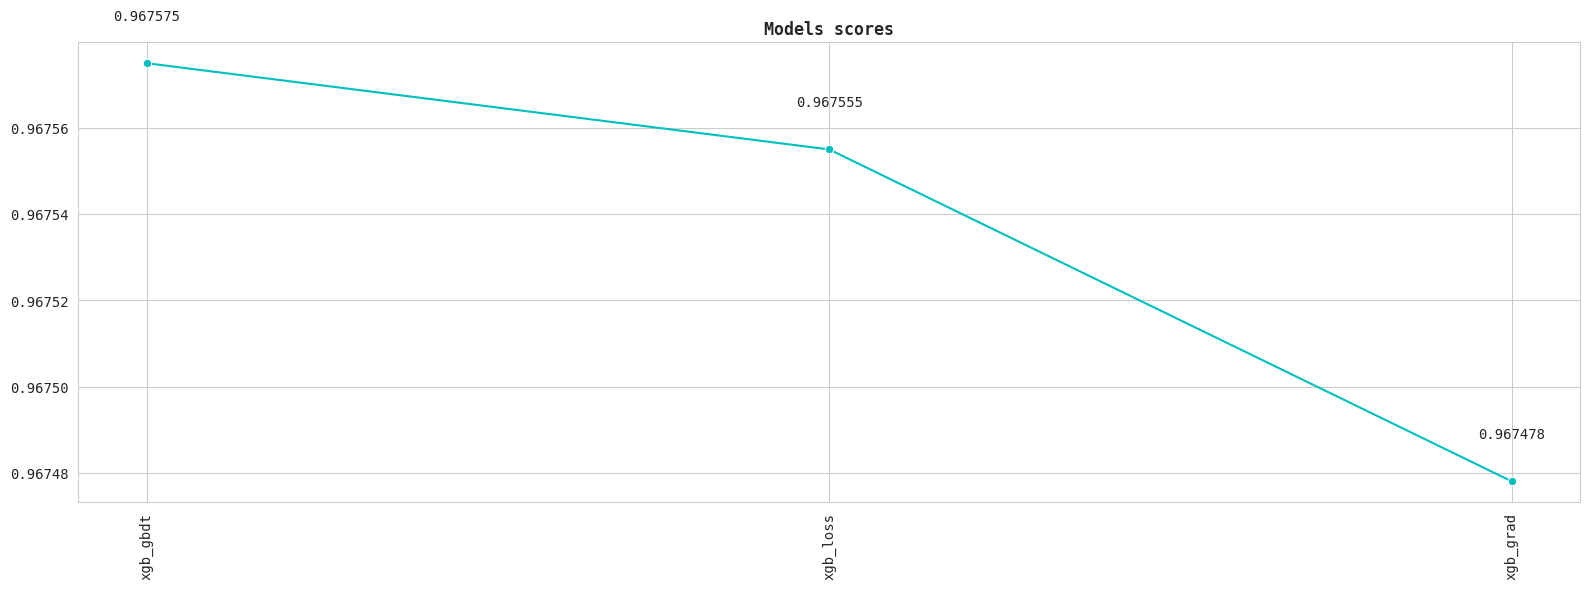

In [40]:
## -- Get Scores --
all_scores = {}

for k, v in all_predictions.items():
    for x, y in v.items():
        if x == "score":
            all_scores[k] = y

plt.figure(figsize=(16, 6))
ax = sns.lineplot(all_scores, marker='o')

# ax.fill_between(range(len(all_model_scores)), all_model_scores.values(), alpha=0.1)
ax.set_title("Models scores", fontweight="semibold")
ax.tick_params('x', rotation=90)
# ax.set_ylim(0.96, 0.968)

add_ = 1e-5
for i, s in enumerate(all_scores.values()):
    ax.text(float(i), s+add_, s, ha="center", va="baseline")

plt.tight_layout()
plt.show()

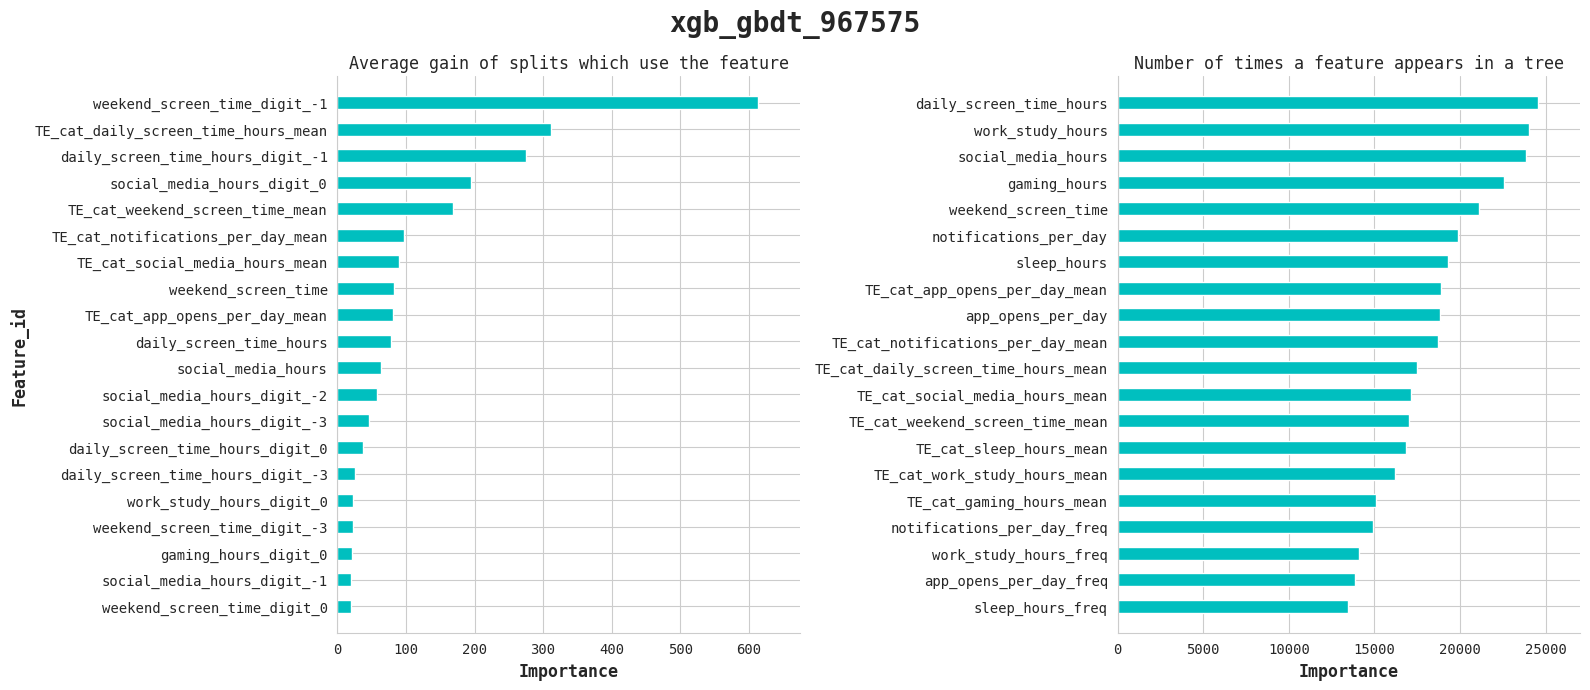

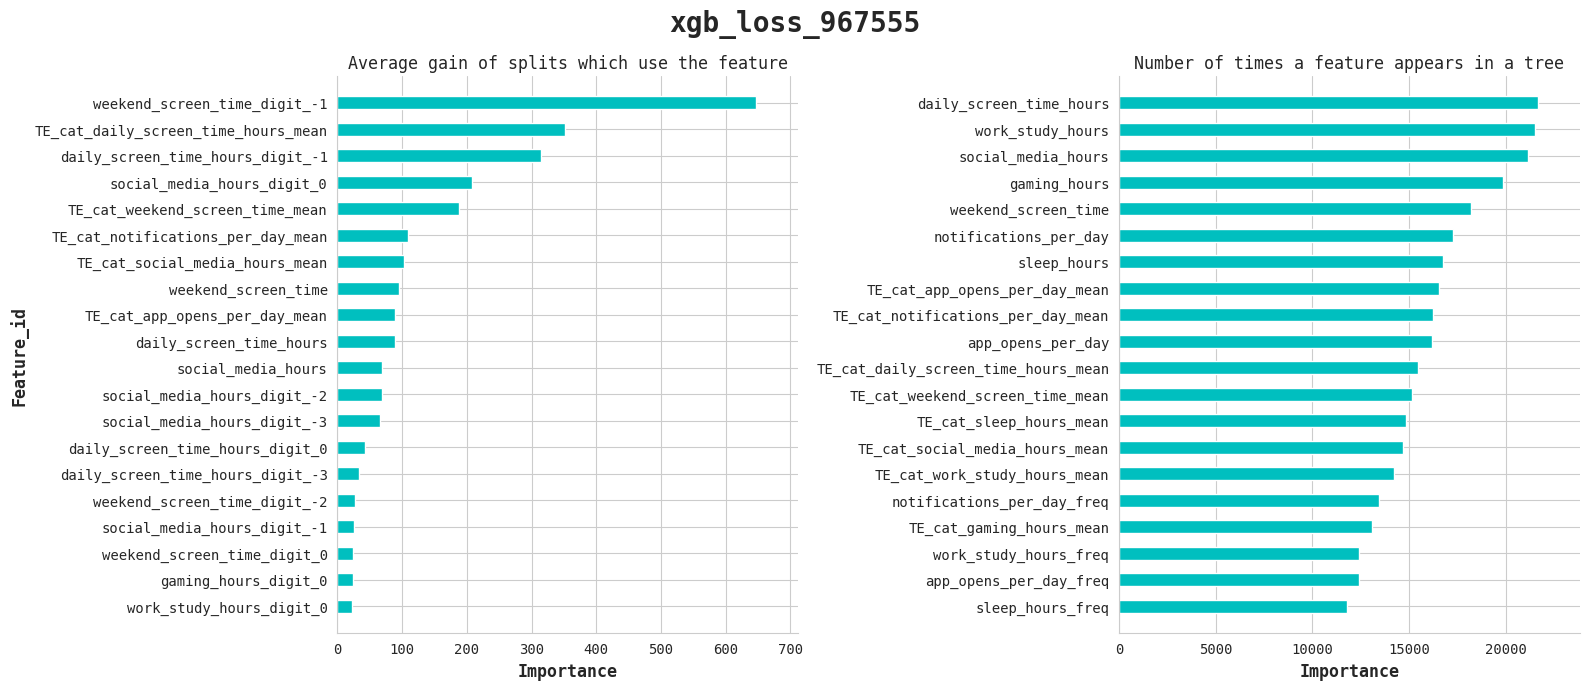

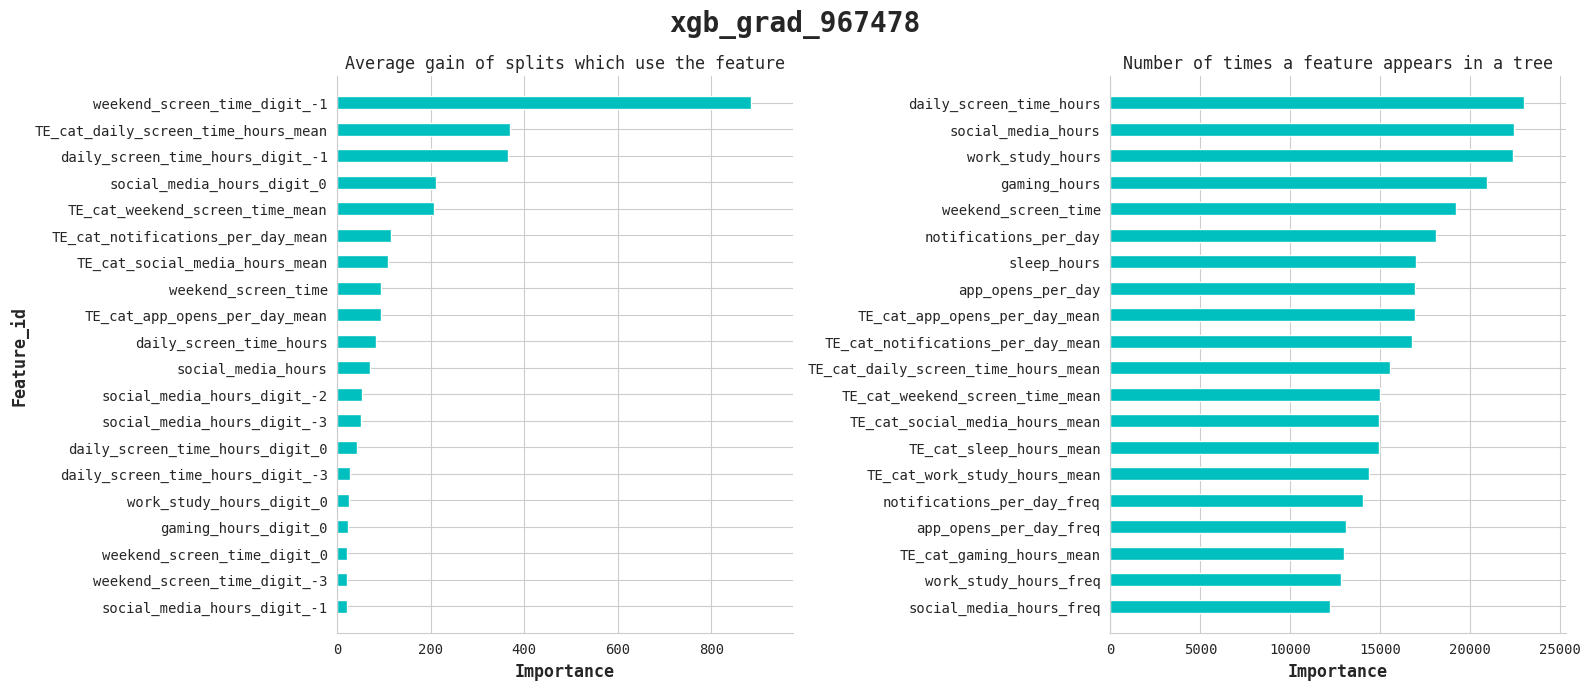

In [41]:
plot_feature_importances(max_cols=20)

xgb_gbdt_967575 saved!


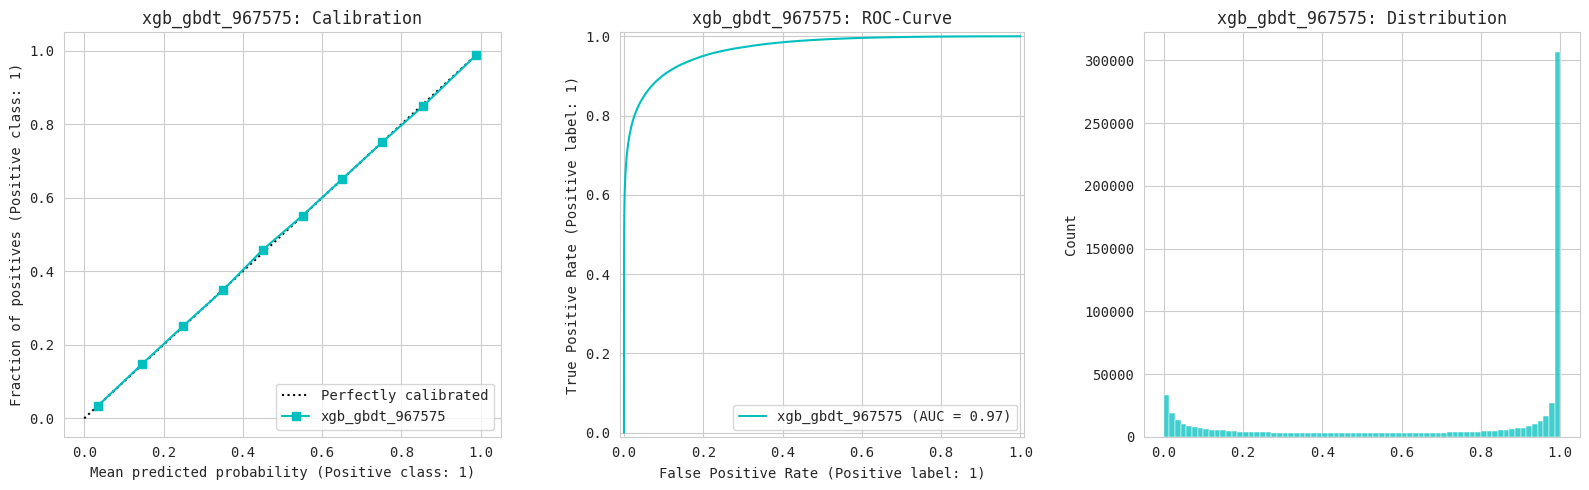


xgb_loss_967555 saved!


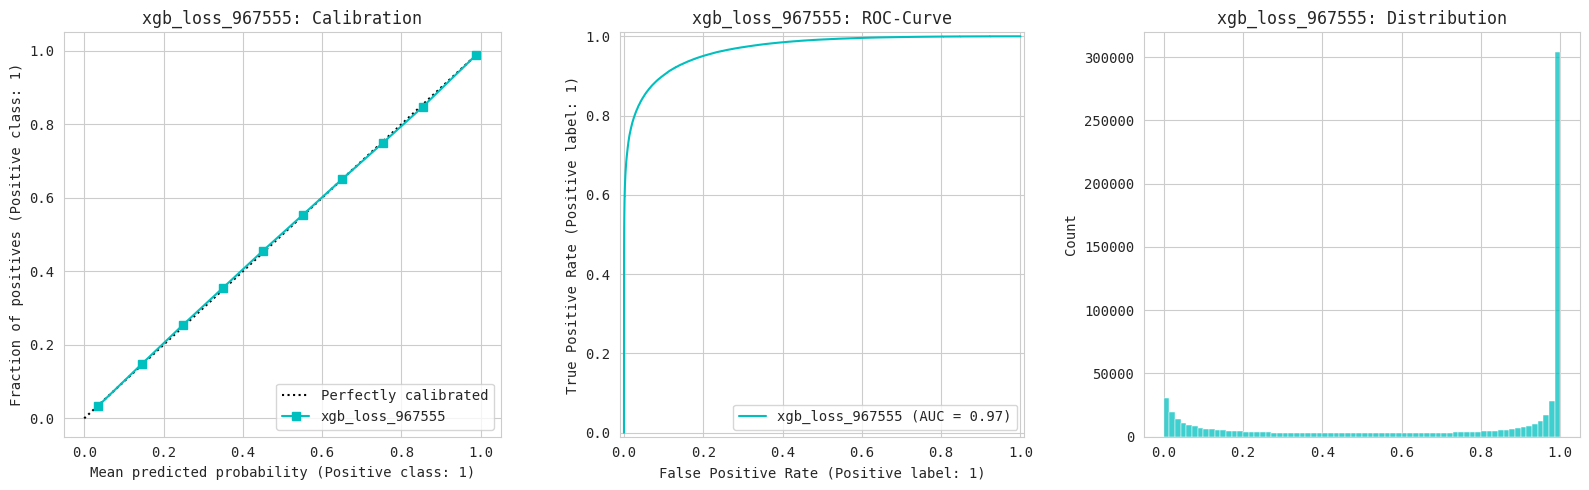


xgb_grad_967478 saved!


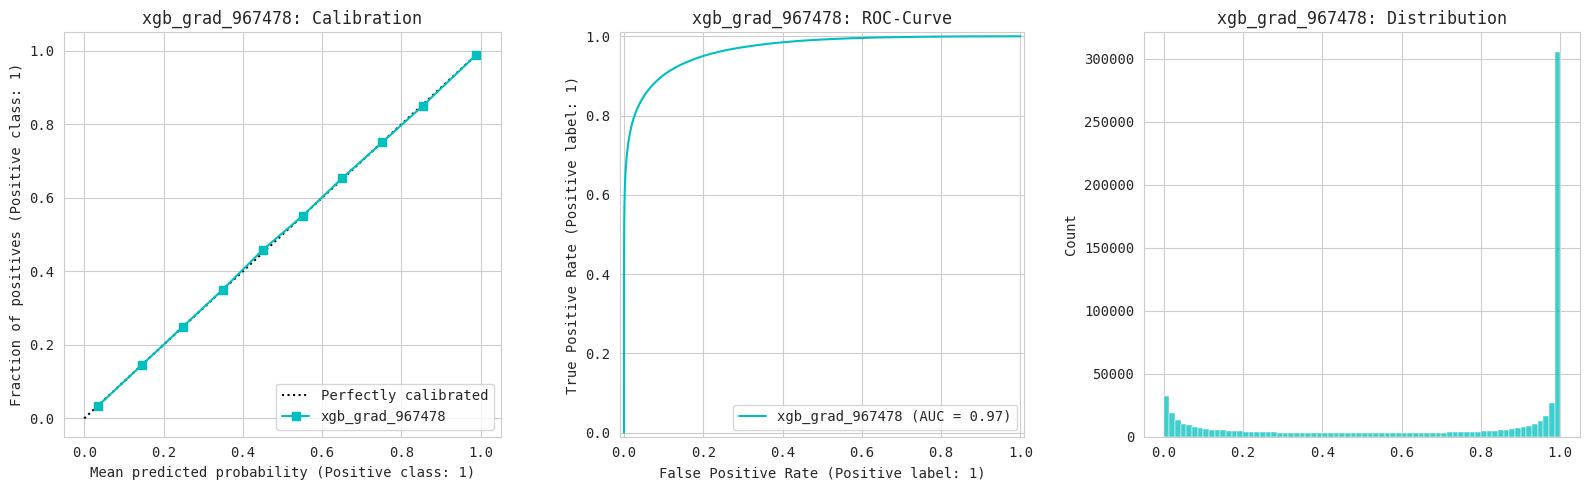

In [42]:
## -- Get oof predictions --
oof_predictions = []

for i, (k, v) in enumerate(all_predictions.items()):
    for key_, data_ in v.items():
        if key_ == "oof_preds":
            ## -- Save oof predictions --
            n = f"{k}_{str(all_scores[k]).split('.')[1]}"
            np.save(f"oof_{n}.npy", data_)
            print(f"{n} saved!")

            ## -- Plot oof distributions --
            _, axs = plt.subplots(1, 3, figsize=(16, 5)) 
            CalibrationDisplay.from_predictions(train_data[TARGET], data_, n_bins=10, name=n, ax=axs[0])
            axs[0].set_title(f"{n}: Calibration")

            RocCurveDisplay.from_predictions(train_data[TARGET], data_, name=n, ax=axs[1])
            axs[1].set_title(f"{n}: ROC-Curve")

            sns.histplot(data_, ax=axs[2])
            axs[2].set_title(f"{n}: Distribution")
            
            plt.tight_layout()
            plt.show()

            print()

In [43]:
## -- Save test predictions/submissions --
model_results = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for j, (x, y) in enumerate(v.items()):
        if x == "test_preds":
            ## -- Base submission file --
            n = f"{k}_{str(all_scores[k]).split('.')[1]}"
            np.save(f"test_{n}.npy", y)

            submit[TARGET] = y
            submit.to_csv(f"submit_{n}.csv", index=False)
            print(f"{n} saved! {y.shape}")

            model_results[n] = y

xgb_gbdt_967575 saved! (296302,)
xgb_loss_967555 saved! (296302,)
xgb_grad_967478 saved! (296302,)


In [44]:
pd.DataFrame(model_results)

,xgb_gbdt_967575,xgb_loss_967555,xgb_grad_967478
0,0.896979,0.885566,0.882210
1,0.659597,0.649282,0.655033
2,0.755811,0.748331,0.755837
3,0.698976,0.758600,0.703584
4,0.779704,0.791713,0.788509
...,...,...,...
296297,0.967712,0.970866,0.954944
296298,0.776842,0.795665,0.762865
296299,0.746977,0.725321,0.728724
296300,0.614953,0.609895,0.600417
